In [ ]:
import numpy as np
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0, 1, n_steps)
  series = 0.5 *np.sin((time - offsets1) * (freq1 * 10 + 10)) #onda1
  series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) #onda2
  series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5) #ruido
  return series[..., np.newaxis].astype(np.float32) #[batch_size,time_steps,dimensionality]

In [ ]:
#conjunto de treino, teste e validação
n_steps = 50
series = generate_time_series(10000, n_steps+1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

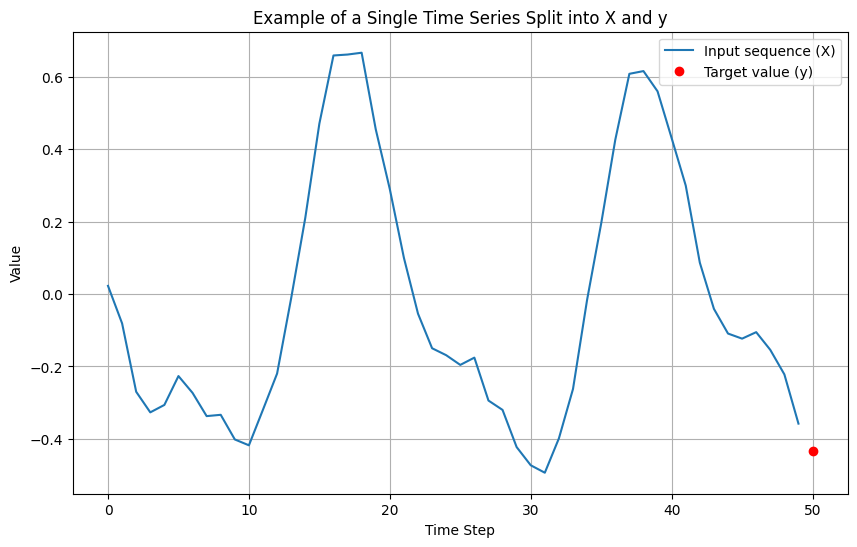

In [ ]:
import matplotlib.pyplot as plt

# Select the first time series for visualization
example_series = series[0, :, 0]

# Split into X (input sequence) and y (target value)
example_X = example_series[:n_steps]
example_y = example_series[-1]

plt.figure(figsize=(10, 6))
plt.plot(range(n_steps), example_X, label='Input sequence (X)')
plt.plot(n_steps, example_y, 'ro', label='Target value (y)')
plt.title('Example of a Single Time Series Split into X and y')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The plot above shows an example of a single time series, where the blue line represents the input sequence `X` (the first `n_steps` values) and the red dot is the target value `y` (the last value of the series).

The dataset (`series`) consists of 10,000 such time series. These are then split into training, validation, and test sets as follows:
- **Training set:** The first 7,000 time series (`series[:7000]`). For each of these, `X_train` contains the first `n_steps` values, and `y_train` contains the last value.
- **Validation set:** Time series from index 7,000 to 9,000 (`series[7000:9000]`). Similar to the training set, `X_valid` and `y_valid` are extracted from these.
- **Test set:** Time series from index 9,000 onwards (`series[9000:]`). `X_test` and `y_test` are extracted from these.

In [ ]:
#np.random.rand(4, 10, 1)

### Alguns modelos de séries temporais (ARIMA etc.) exigem primeiro a remoção da tendência e sazonalidade para treino. Quando o modelo for treinado e começar a fazer predições, você adiciona esta tendência e/ou sazonalidade para fazer as predições finais. Com modelos mais complexos como RNN e variantes, não é necessário em geral, mas pode melhorar, já que o modelo não terá que aprender estes padrões

In [ ]:
from tensorflow import keras
#previsão ingênua (o último valor da série)
y_pred = X_valid[:, -1]
np.mean(keras.losses.MSE(y_valid, y_pred))

np.float32(0.3017774)

##como baseline, vamos treinar um modelo de regressão simples, para que cada predição seja uma combinação linear dos valores na série temporal

In [1]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]), #51 parâmetros treináveis (50 pesos + 1 viés)
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

##Vamos agora usar uma RNN simples (vanilla)

In [2]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

### OBS: o resultado do val_loss da SimpleRNN foi melhor que a rede linear?
### to-do:
### 1) empilhe duas camadas SimpleRNN com 20 unidades cada e no sinal uma SimpleRNN de 1 unidade. Em cada um coloque o hiperparâmetro return_sequences=True. Isto é importante, todas as camadas recorrentes menos a última (a de saída). Com return_sequences=False elas gerarão um array 2D (contendo apenas a saída do último intervalo de tempo). Com return_sequences=True, retorna todas as saídas para todos os intervalos de tempo. Treine da mesma forma e compare o MSE.

### to-do:
### 2) altere a última camada para Dense(1). Observa mudança no tempo de treino?

### No código abaixo, geramos a série com 10 passos a mais, o "futuro" que queremos prever

In [13]:
series = generate_time_series(10000, n_steps+10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]

Y = np.empty((10000, n_steps, 10)) #cada target é uma sequência de 10 vetores 10D
for step_ahead in range(1, 10 + 1):
  Y[:, :, step_ahead - 1] = series[:, step_ahead:step_ahead + n_steps, 0]

Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True), #seq2seq (última RNN)
    keras.layers.TimeDistributed(keras.layers.Dense(10)) #conv1D(n,filter_size=1)
])

#obter o MSE em relação à saída no último intervalo de tempo
def last_time_step_mse(Y_true, Y_pred):
  return keras.metrics.MSE(Y_true[:, -1], Y_pred[:, -1])

optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss="mse", optimizer=optimizer, metrics=[last_time_step_mse])

history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


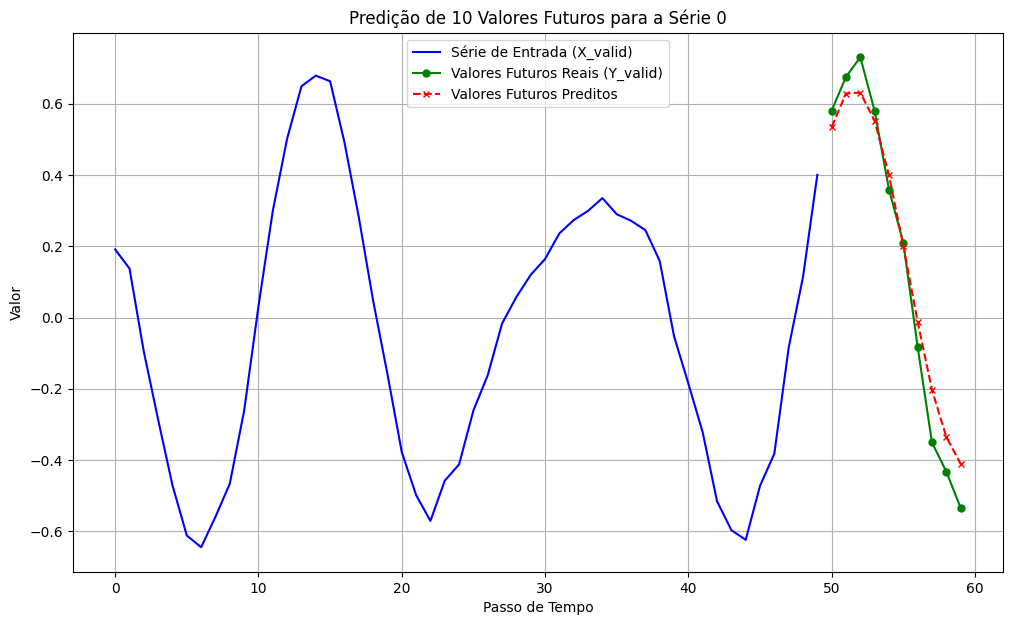

In [ ]:
import matplotlib.pyplot as plt

# Selecionar uma série de exemplo para predição e visualização
# Vamos pegar o primeiro exemplo do conjunto de validação
example_index = 0

# A entrada para o modelo deve ter a forma (batch_size, n_steps, 1)
# Portanto, X_valid[example_index:example_index+1] mantém as dimensões corretas
example_X_input = X_valid[example_index:example_index+1]

# Fazer a predição
# O modelo retorna (batch_size, n_steps, 10), onde 10 são as 10 predições futuras
# Para o último passo de tempo da sequência de entrada, queremos as 10 predições
predicted_future = model.predict(example_X_input)[0, -1, :]

# Obter os valores futuros reais correspondentes para comparação
# Y_valid tem a forma (batch_size, n_steps, 10)
actual_future = Y_valid[example_index, -1, :]

# Plotar os resultados
plt.figure(figsize=(12, 7))

# Plotar a série de entrada (X_valid)
plt.plot(range(n_steps), X_valid[example_index, :, 0], label='Série de Entrada (X_valid)', color='blue')

# Plotar os valores futuros reais
# Começamos a plotar a partir de n_steps para indicar que são valores futuros
plt.plot(range(n_steps, n_steps + 10), actual_future, 'go-', label='Valores Futuros Reais (Y_valid)', markersize=5)

# Plotar os valores futuros previstos
plt.plot(range(n_steps, n_steps + 10), predicted_future, 'rx--', label='Valores Futuros Preditos', markersize=5)

plt.title(f'Predição de 10 Valores Futuros para a Série {example_index}')
plt.xlabel('Passo de Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()